<a href="https://colab.research.google.com/github/braulioalda4-code/Modelos_de_aprendizaje/blob/main/Practica_U1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Importa NumPy para realizar operaciones matemáticas y manipulación de arreglos
import numpy as np
# Importa Pandas para trabajar con estructuras de datos tabulares
import pandas as pd
# Importa Matplotlib para generar gráficos
import matplotlib.pyplot as plt
# Importa el conjunto de datos California Housing desde Scikit-learn
from sklearn.datasets import fetch_california_housing

In [23]:
# Carga el conjunto de datos California Housing
data = fetch_california_housing()

as_frame = True

# Muestra la descripción general del conjunto de datos
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [24]:
import pandas as pd

# Obtiene las características de entrada y las almacena en un DataFrame
X = data.data

# Obtiene la variable que queremos predecir y la almacena en una Serie
y = data.target

# Muestra los primeros cinco registros de las variables de entrada
print(X.head())

# Muestra los primeros cinco valores de la variable objetivo
print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [25]:
# Obtiene el número de filas y columnas de las variables de entrada
print ("Dimensiones de X:", X.shape)
# Obtiene el número de elementos de la variable objetivo
print ("Número de valores de y:", y.shape)

Dimensiones de X: (20640, 8)
Número de valores de y: (20640,)


In [26]:
# Muestra los nombres de las variables predictoras
print (X.columns)
# Calcula estadísticas descriptivas de las variables
print (X.describe())

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std

In [27]:
# Calcula estadísticas descriptivas de la variable objetivo
print (y.describe())

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


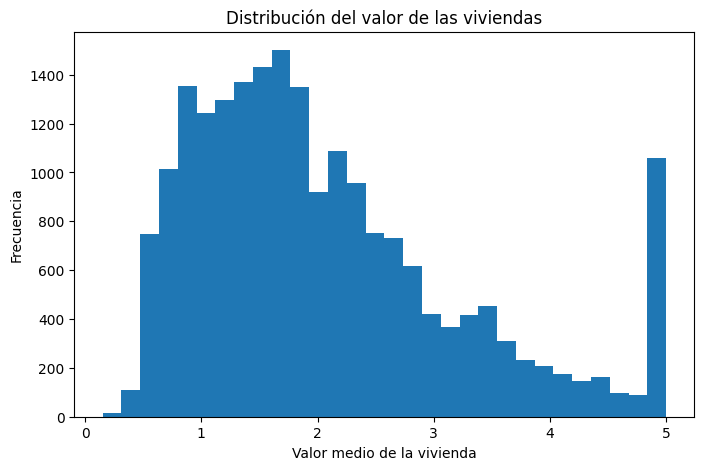

In [28]:
# Crea una figura de tamaño 8 x 5 pulgadas
plt.figure(figsize=(8, 5))

# Genera un histograma utilizando 30 intervalos
plt.hist(y, bins=30)

# Define el nombre del eje X
plt.xlabel("Valor medio de la vivienda")

# Define el nombre del eje Y
plt.ylabel("Frecuencia")

# Agrega un título al gráfico
plt.title("Distribución del valor de las viviendas")

# Muestra el gráfico
plt.show()

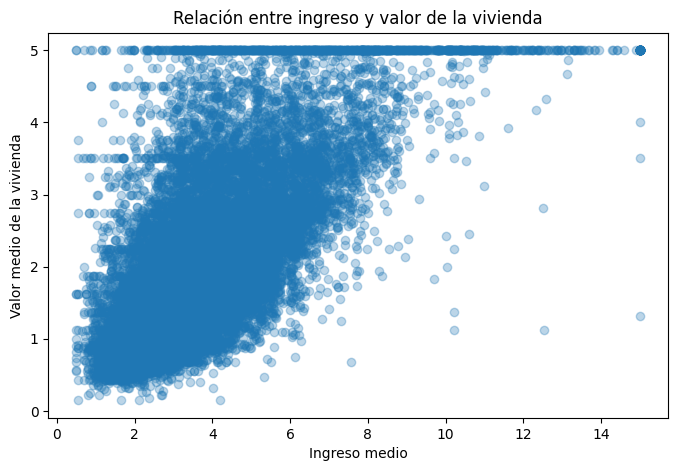

In [29]:
# Crea una figura de tamaño 8 x 5
plt.figure(figsize=(8, 5))

# Grafica el ingreso medio en el eje X y el valor de la vivienda en el eje Y
plt.scatter(X["MedInc"], y, alpha=0.3)

# Etiqueta el eje X
plt.xlabel("Ingreso medio")

# Etiqueta el eje Y
plt.ylabel("Valor medio de la vivienda")

# Agrega un título
plt.title("Relación entre ingreso y valor de la vivienda")

# Muestra la gráfica
plt.show()

In [30]:
# Selecciona únicamente la variable MedInc
X_simple = X[["MedInc"]]

In [31]:
# Importa la función para dividir un conjunto de datos
from sklearn.model_selection import train_test_split
#Divide los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,       # Variables de entrada
    y,              # Variable Objetivo
    test_size=0.2,  # Utiliza el 20 % de los datos para pruba
    random_state=42 # Permite reproducir exactamente la misma división
)

In [32]:
# Importa el modelo de regresion lineal
from sklearn.linear_model import LinearRegression

In [33]:
# Crea un objeto que representa el modelo de regresion
modelo = LinearRegression()

In [34]:
# Entrena el modelo utilizando la variables de entrada y los valores conocidos
modelo.fit (X_train, y_train)

LinearRegression()

In [35]:
# Muestra el valor del intercepto
print("Intercepto:", modelo.intercept_)

Intercepto: 0.4445972916907879


In [36]:
# Muestra el coeficiente asociado con MedInc
print("Coeficiente:", modelo.coef_[0])

Coeficiente: 0.4193384939381271


In [37]:
# Utiliza el modelo entrenado para generar predicciones
y_pred = modelo.predict(X_test)

In [38]:
# Muestra los primeros diez valores reales
print("Valores reales:")
print(y_test.iloc[:10].values)

Valores reales:
[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


In [39]:
# Muestra las primeras diez predicciones
print ("Predicciones:")
print (y_pred[:10])

Predicciones:
[1.14958917 1.50606882 1.90393718 2.85059383 2.00663318 2.42165249
 2.57647226 1.99229181 2.45893168 3.84677436]


In [40]:
# Importa métricas utilizadas para evaluar modelos
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [41]:
# Calcula el error absoluto medio
mae = mean_absolute_error(y_test, y_pred)

# Calcula el error cuadrático medio
mse = mean_squared_error(y_test, y_pred)

# Calcula la raíz cuadrada del error cuadrático medio
rmse = np.sqrt(mse)

# Calcula el coeficiente de determinación
r2 = r2_score(y_test, y_pred)

In [42]:
# Imprime las cuatro métricas calculadas
print ("MAE :", mae)
print ("MSE :", mse)
print ("RMSE :", rmse)
print ("R2 :", r2)

MAE : 0.629908653009376
MSE : 0.7091157771765549
RMSE : 0.8420901241414455
R2 : 0.45885918903846656


In [43]:
# Crea una figura
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

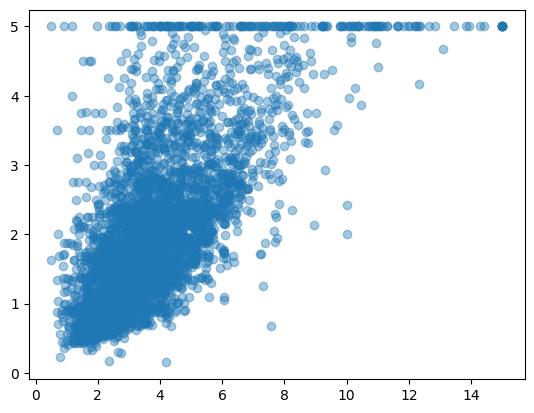

In [44]:
# Grafica los valores reales del conjunto de prueba
plt.scatter(
    X_test["MedInc"],
    y_test,
    alpha=0.4,
    label="Datos reales"
)

In [45]:
# Ordena los valores de X para que la línea se dibuje correctamente
orden = np.argsort (X_test["MedInc"].values)

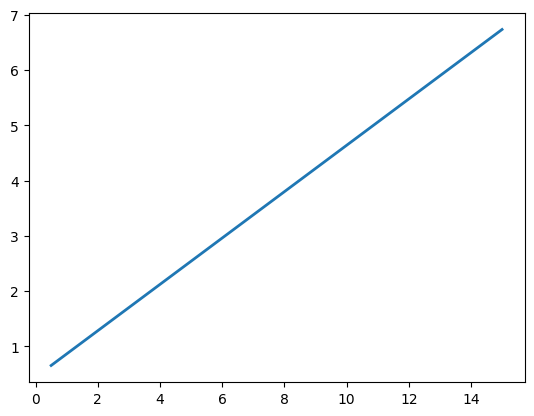

In [46]:
# Dibuja la línea correspondiente a las predicciones
plt.plot(
    X_test["MedInc"].values[orden],
    y_pred[orden],
    linewidth=2,
    label="Regresión lineal"
)

/tmp/ipykernel_3791/3733294876.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


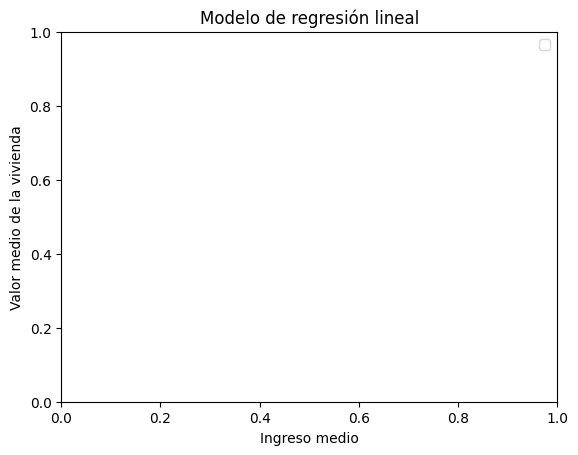

In [47]:
# Etiqueta el eje x
plt.xlabel("Ingreso medio")
# Etiqueta el eje y
plt.ylabel("Valor medio de la vivienda")
# Agrega el título
plt.title("Modelo de regresión lineal")
# Muestra la leyenda
plt.legend()
# Muestra la gráfica
plt.show()

In [48]:
# Crea una tabla con los valores reales y las predicciones
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred
})

# Calcula el error entre el valor real y el predicho
comparacion["Error"] = (
    comparacion["Real"] - comparacion["Predicción"]
)

# Muestra los primeros diez registros
print(comparacion.head(10))

      Real  Predicción     Error
0  0.47700    1.149589 -0.672589
1  0.45800    1.506069 -1.048069
2  5.00001    1.903937  3.096073
3  2.18600    2.850594 -0.664594
4  2.78000    2.006633  0.773367
5  1.58700    2.421652 -0.834652
6  1.98200    2.576472 -0.594472
7  1.57500    1.992292 -0.417292
8  3.40000    2.458932  0.941068
9  4.46600    3.846774  0.619226


In [49]:
# Calcula el valor absoluto del error
comparacion["Error_Absoluto"] = (
    comparacion["Error"].abs()
)

# Ordena los registros de mayor a menor error
mayores_errores = comparacion.sort_values(
    "Error_Absoluto",
    ascending = False
)

# Muestra los diez casos con mayor error
print(mayores_errores.head(10))

         Real  Predicción     Error  Error_Absoluto
1649  5.00001    0.654225  4.345785        4.345785
1138  5.00001    0.822002  4.178008        4.178008
1865  5.00001    0.935056  4.064954        4.064954
1140  5.00001    1.268975  3.731035        3.731035
3761  5.00001    1.437339  3.562671        3.562671
2574  5.00001    1.481286  3.518724        3.518724
1655  5.00001    1.517601  3.482409        3.482409
3054  5.00001    1.529636  3.470374        3.470374
3231  4.50000    1.079140  3.420860        3.420860
429   5.00001    1.588343  3.411667        3.411667


In [50]:
random_state=42

In [51]:
# Utiliza todas las variables disponibles como características de entrada
X_multiple = X

In [52]:
# Divide las características y la variable objetivo en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_multiple,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
# Crea un nuevo modelo de regresion lineal
modelo_multiple = LinearRegression()

In [54]:
# Entrena el modelo utilizando todas las variables
modelo_multiple.fit(X_train, y_train)

LinearRegression()

In [56]:
# Genera las predicciones del modelo múltiple
y_pred_multiple = modelo_multiple.predict(X_test)

# Calcula el MAE del modelo múltiple
mae_multiple = mean_absolute_error(
    y_test,
    y_pred_multiple
)

# Calcula el RMSE del modelo múltiple
rmse_multiple = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_multiple
    )
)

In [57]:
# Calcula el R2 del modelo múltiple
r2_multiple = r2_score(
    y_test,
    y_pred_multiple
)

# Muestra los resultados
print("MAE:", mae_multiple)
print("RMSE:", rmse_multiple)
print("R2:", r2_multiple)

MAE: 0.5332001304956553
RMSE: 0.7455813830127764
R2: 0.5757877060324508
